In [1]:
import pandas as pd

# load dataset
df = pd.read_csv("mnist_train.csv")

print(df.shape)
print(df.head())

(60000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [2]:
print(df.info())
print(df.isnull().sum().sum())
print(df['label'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None
0
label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64


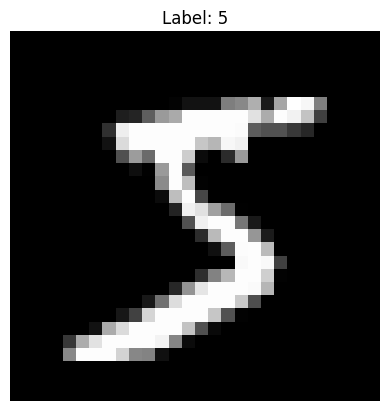

In [3]:
import matplotlib.pyplot as plt

# pick one sample
image = df.iloc[0, 1:].values.reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {df.iloc[0, 0]}")
plt.axis('off')
plt.show()

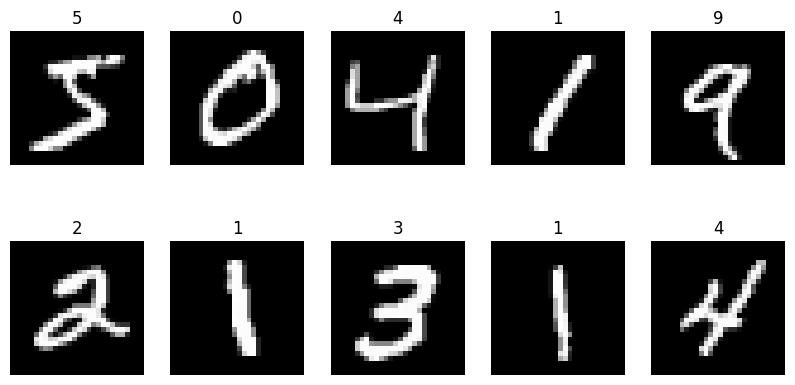

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(df.iloc[i, 0])
    ax.axis('off')

plt.show()

In [5]:
X = df.drop("label", axis=1)
y = df["label"]

In [6]:
X = X / 255.0

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

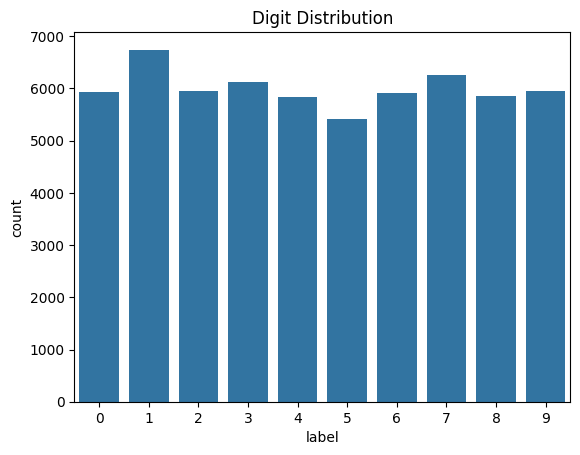

In [8]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Digit Distribution")
plt.show()

<Axes: >

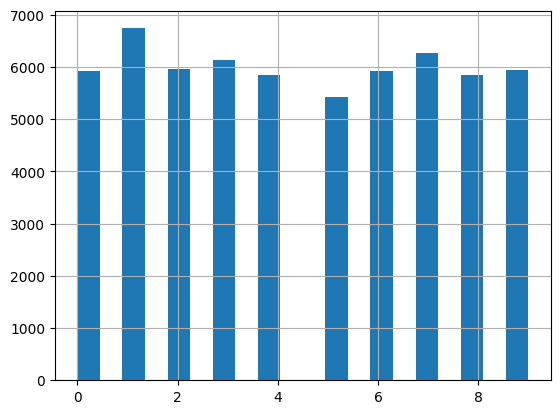

In [12]:
df['label'].hist(bins=20)

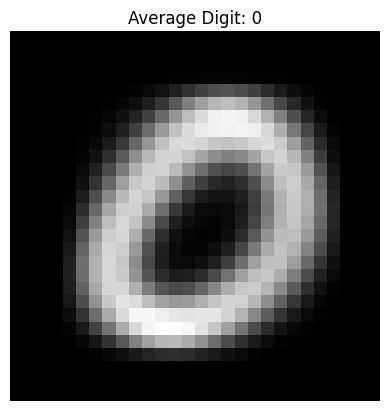

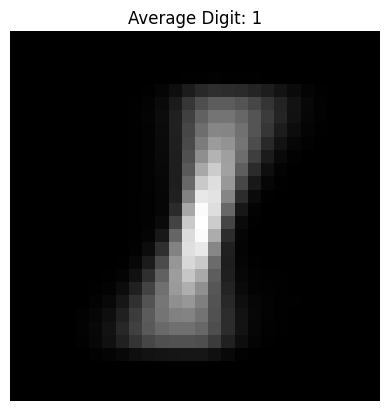

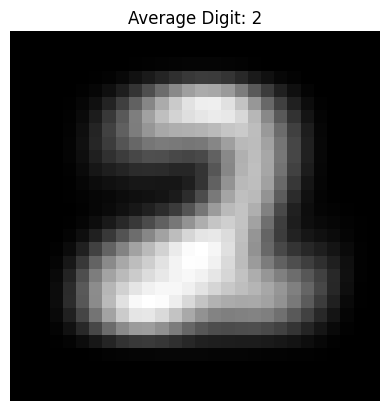

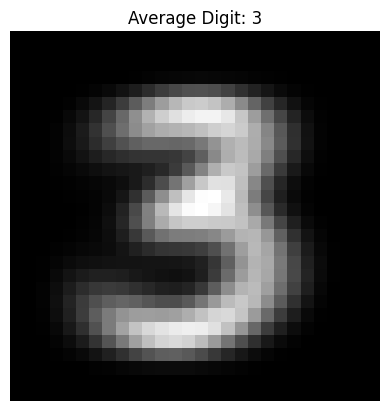

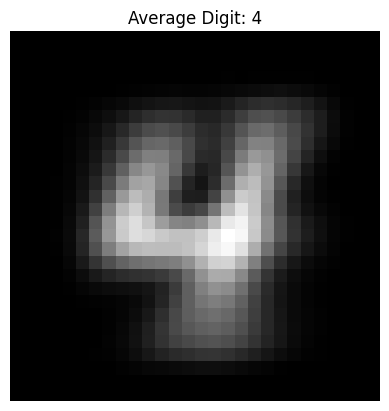

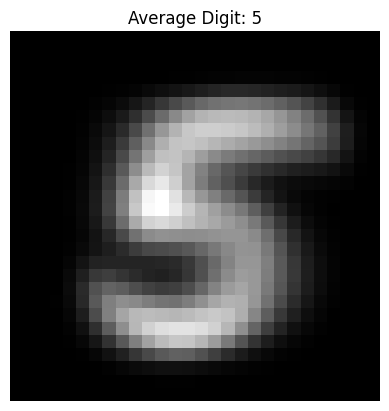

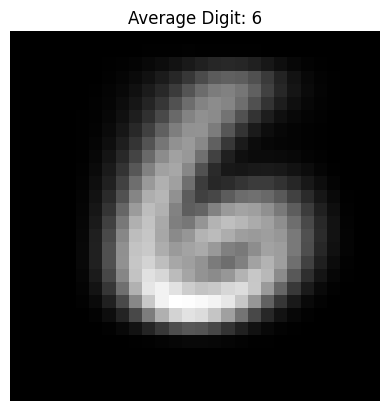

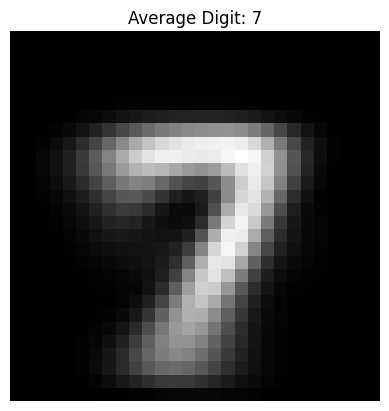

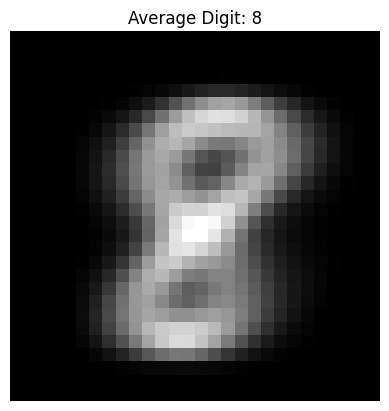

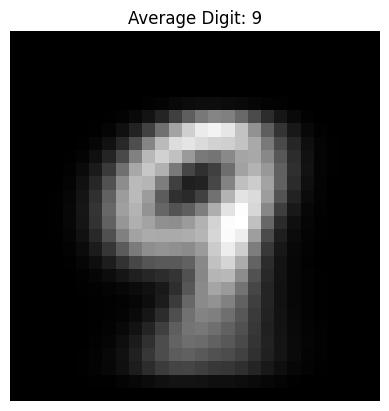

In [14]:
import numpy as np

for digit in range(10):
    mean_img = X[y == digit].mean().values.reshape(28, 28)
    
    plt.imshow(mean_img, cmap='gray')
    plt.title(f"Average Digit: {digit}")
    plt.axis('off')
    plt.show()

In [ ]:
# from sklearn.svm import SVC

# # create model
# svm_model = SVC(kernel='rbf')

# # train
# svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# y_pred = svm_model.predict(X_test)

In [21]:
# hyperparamter tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

params = {
    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), params, cv=3, verbose=2)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time= 7.6min
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time= 5.4min
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time= 7.2min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 6.8min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 6.9min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time= 8.8min
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time= 6.3min
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time= 7.3min
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time= 6.6min
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time= 5.5min
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time= 3.7min
[CV] END .......................C=10, gamma=0.01,

In [22]:
from sklearn.metrics import accuracy_score
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))

Improved Accuracy: 0.9835833333333334


In [23]:
from sklearn.metrics import classification_report
print("after hyperparameter tuning:\n")
print(classification_report(y_test, y_pred))

after hyperparameter tuning:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.99      1.00      0.99      1322
           2       0.97      0.99      0.98      1174
           3       0.99      0.97      0.98      1219
           4       0.98      0.99      0.98      1176
           5       0.98      0.98      0.98      1104
           6       0.99      0.99      0.99      1177
           7       0.99      0.98      0.98      1299
           8       0.98      0.98      0.98      1160
           9       0.98      0.97      0.98      1194

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



In [ ]:
# from sklearn.metrics import accuracy_score

# print("Accuracy:", accuracy_score(y_test, y_pred))
# Accuracy: 0.9775833333333334

Accuracy: 0.9775833333333334


In [ ]:
# from sklearn.metrics import classification_report

# print(classification_report(y_test, y_pred))

# precision    recall  f1-score   support

#            0       0.99      0.99      0.99      1175
#            1       0.99      0.99      0.99      1322
#            2       0.96      0.98      0.97      1174
#            3       0.98      0.96      0.97      1219
#            4       0.97      0.98      0.98      1176
#            5       0.98      0.97      0.97      1104
#            6       0.99      0.99      0.99      1177
#            7       0.98      0.97      0.98      1299
#            8       0.97      0.97      0.97      1160
#            9       0.97      0.97      0.97      1194

#     accuracy                           0.98     12000
#    macro avg       0.98      0.98      0.98     12000
# weighted avg       0.98      0.98      0.98     12000

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.99      0.99      0.99      1322
           2       0.96      0.98      0.97      1174
           3       0.98      0.96      0.97      1219
           4       0.97      0.98      0.98      1176
           5       0.98      0.97      0.97      1104
           6       0.99      0.99      0.99      1177
           7       0.98      0.97      0.98      1299
           8       0.97      0.97      0.97      1160
           9       0.97      0.97      0.97      1194

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



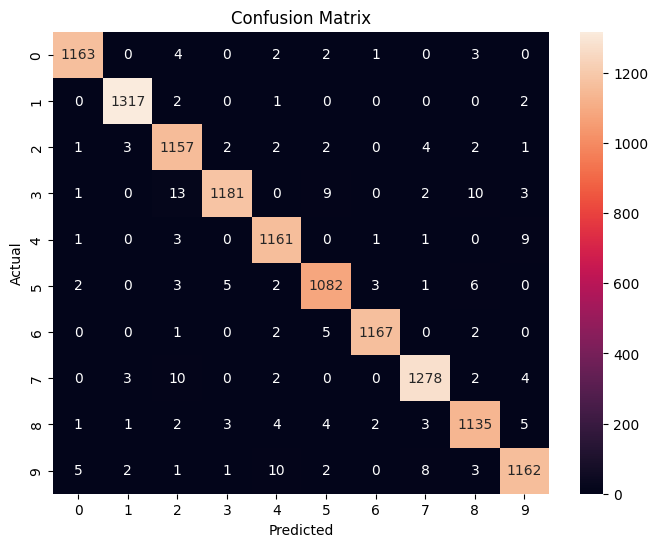

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

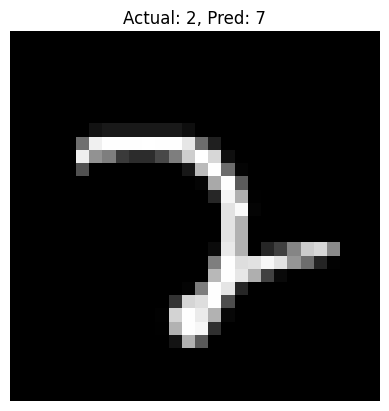

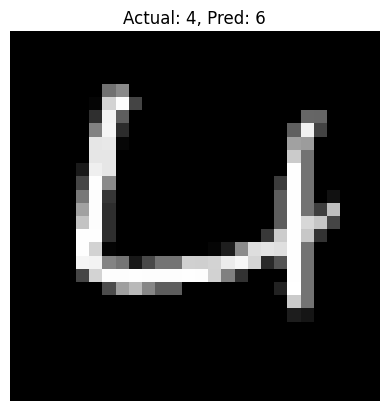

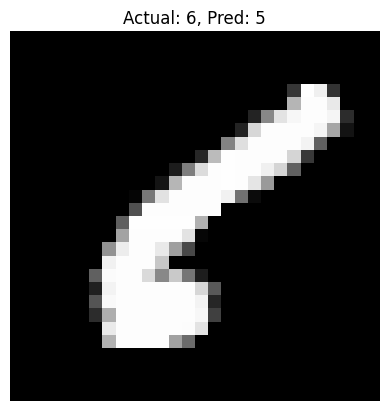

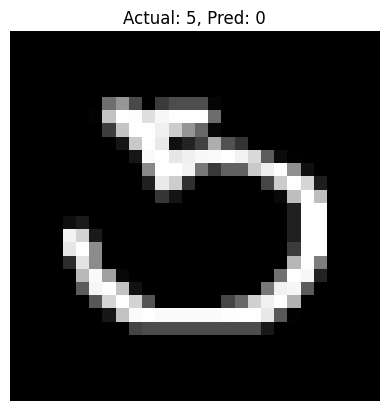

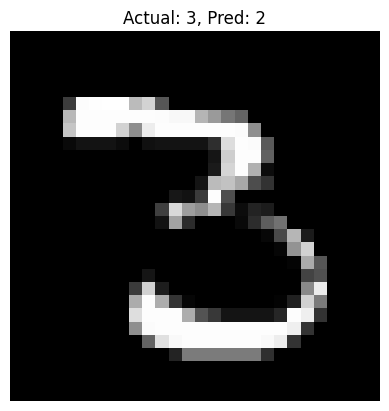

In [25]:
import numpy as np

wrong = np.where(y_pred != y_test)[0]

for i in wrong[:5]:
    img = X_test.iloc[i].values.reshape(28,28)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {y_test.iloc[i]}, Pred: {y_pred[i]}")
    plt.axis('off')
    plt.show()

In [26]:
import joblib

joblib.dump(best_model, "svm_mnist.pkl")

['svm_mnist.pkl']